In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import sqlite3


Load in the data and get an overview.
Dont use all of it, but its nice to have.

In [2]:
# Load in dataset using pandas
df = pd.read_csv("data\Sales_with_NaNs_v1.3.csv")

# Info to get a basic look at the data and how many non-null values there are
df.info()

# Basic info on missing value
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Group                         8599 non-null   object 
 1   Customer_Segment              8034 non-null   object 
 2   Sales_Before                  8478 non-null   float64
 3   Sales_After                   9233 non-null   float64
 4   Customer_Satisfaction_Before  8330 non-null   float64
 5   Customer_Satisfaction_After   8360 non-null   float64
 6   Purchase_Made                 9195 non-null   object 
dtypes: float64(4), object(3)
memory usage: 547.0+ KB
Group                           1401
Customer_Segment                1966
Sales_Before                    1522
Sales_After                      767
Customer_Satisfaction_Before    1670
Customer_Satisfaction_After     1640
Purchase_Made                    805
dtype: int64


<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:2: SyntaxWarning: invalid escape sequence '\S'
C:\Users\rasmu\AppData\Local\Temp\ipykernel_29164\2184562955.py:2: SyntaxWarning: invalid escape sequence '\S'
  df = pd.read_csv("data\Sales_with_NaNs_v1.3.csv")


Below is a very good way to indicate if my missing data is MAR or MCAR

I do this by comparing how much of the data in a feature is missing in quantiles, and then looking for patterns.

The numbers below sugest that it is MCAR(Missing Completely At Random), as it has very little variance in "Missingness". If there were bigger differences in missingness, it would sugest at pattern, and be more MAR.


SMALL TUTORIAL: ( DONT READ IF YOU DONT WANT TO)
I first choose a target column from the dataset, that i can check up against the other columns. 
I then create a "missing indicator", that returns boolean True or False, based on if the instance is missing. This will be used to go through each instance in the column, to check if a datapoint is missing.

Each numerical column is binned in 4 bins, which is sorted as quantiles, so we can observe if there is any trends with missing values in the lower, midle and higher values.

If it detects other than numerical datatypes for a column, it will skip the categorisation, as it is already a category. (like "Costumer_Segment")

Because we have made the columns into "missing data boolean check" we can take the mean of the output, and it will output a procent of how much data is missing in that specific quantile, based on the target column. Example: "is_missing" is a list of False/True, which indicates if a value is missing. I make this into 1 and 0. This is 1 for missing and 0 for not missing. The list looks like this [0,1,1,0,0,0,1]. Now i take the mean like so:(1+1+1)/7= 0.4, which means 40% is missing, wow!




In [3]:


# Loop through each column that has missing values
for target_col in df:
    print(f"\n Missing pattern for: {target_col}")

    # Create a missing indicator. 
    is_missing = df[target_col].isnull()

    # Loop through other columns to check if "missingness" depends on them
    for other_col in df.columns:
        if other_col != target_col:
            print(f"\nGrouped by: {other_col}")

            # If the other column is numeric, bin it first (to make categories)
            if pd.api.types.is_numeric_dtype(df[other_col]):
                binned = pd.qcut(df[other_col], q=4, duplicates='drop')
                grouped = is_missing.groupby(binned, observed=True).mean()
            else:
                grouped = is_missing.groupby(df[other_col], observed=True).mean()

            print(grouped)


 Missing pattern for: Group

Grouped by: Customer_Segment
Customer_Segment
High Value      0.137604
Low Value       0.147462
Medium Value    0.143864
Name: Group, dtype: float64

Grouped by: Sales_Before
Sales_Before
(24.852, 166.629]     0.148585
(166.629, 203.324]    0.136385
(203.324, 238.809]    0.139217
(238.809, 545.423]    0.141038
Name: Group, dtype: float64

Grouped by: Sales_After
Sales_After
(32.413000000000004, 221.437]    0.152447
(221.437, 273.129]               0.136482
(273.129, 332.57]                0.132149
(332.57, 818.22]                 0.144281
Name: Group, dtype: float64

Grouped by: Customer_Satisfaction_Before
Customer_Satisfaction_Before
(22.201, 56.366]    0.147864
(56.366, 69.491]    0.142651
(69.491, 83.427]    0.131604
(83.427, 100.0]     0.143543
Name: Group, dtype: float64

Grouped by: Customer_Satisfaction_After
Customer_Satisfaction_After
(18.224, 59.925]    0.147847
(59.925, 73.845]    0.137799
(73.845, 90.044]    0.144976
(90.044, 100.0]     0.1373

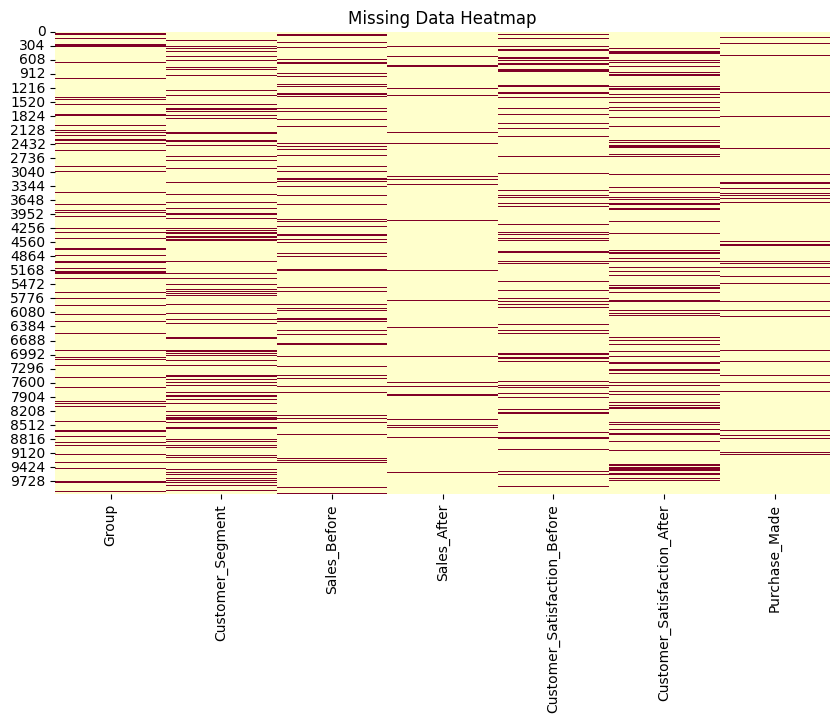

In [4]:
# Heatmap for missing data
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='YlOrRd')
plt.title("Missing Data Heatmap")
plt.show()

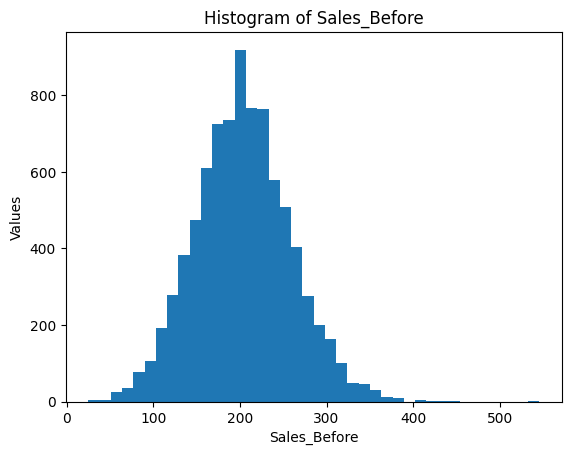

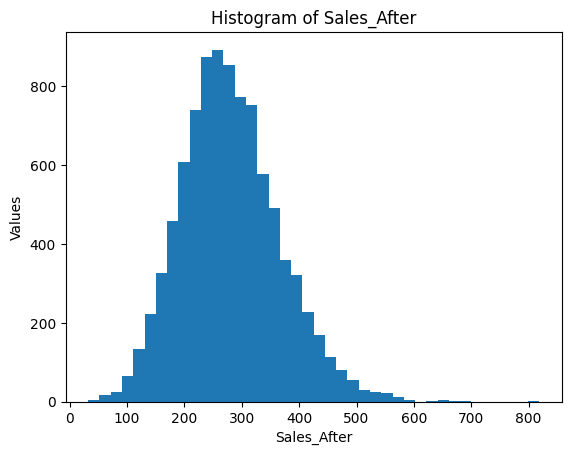

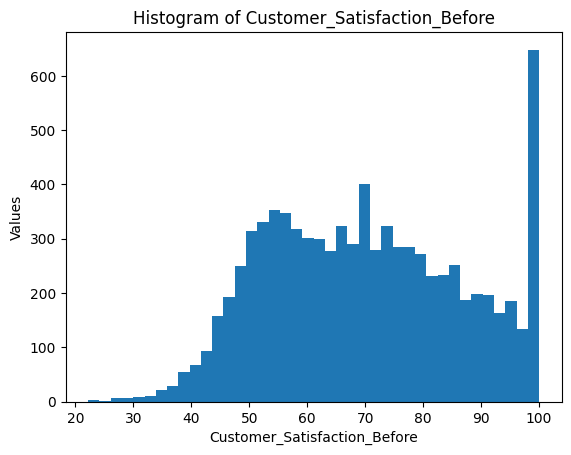

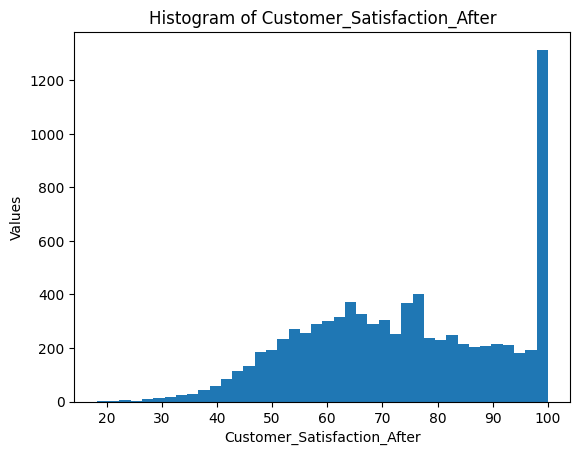

In [5]:
# Isolate numeric and categorical features
numeric_columns = df.select_dtypes(include='number').columns
categorical_cols = df.select_dtypes(include='object').columns
# Shows histograms method
def histogram_shower(data, column_name):
    plt.hist(data[column_name], bins=40)
    plt.xlabel(column_name)
    plt.ylabel("Values")
    plt.title(f"Histogram of {column_name}")
    plt.show()

# Loop through all the histograms in the df (only numerical values ofcourse)
for col in numeric_columns:
    histogram_shower(df, col)

Index(['Group', 'Customer_Segment', 'Purchase_Made'], dtype='object')


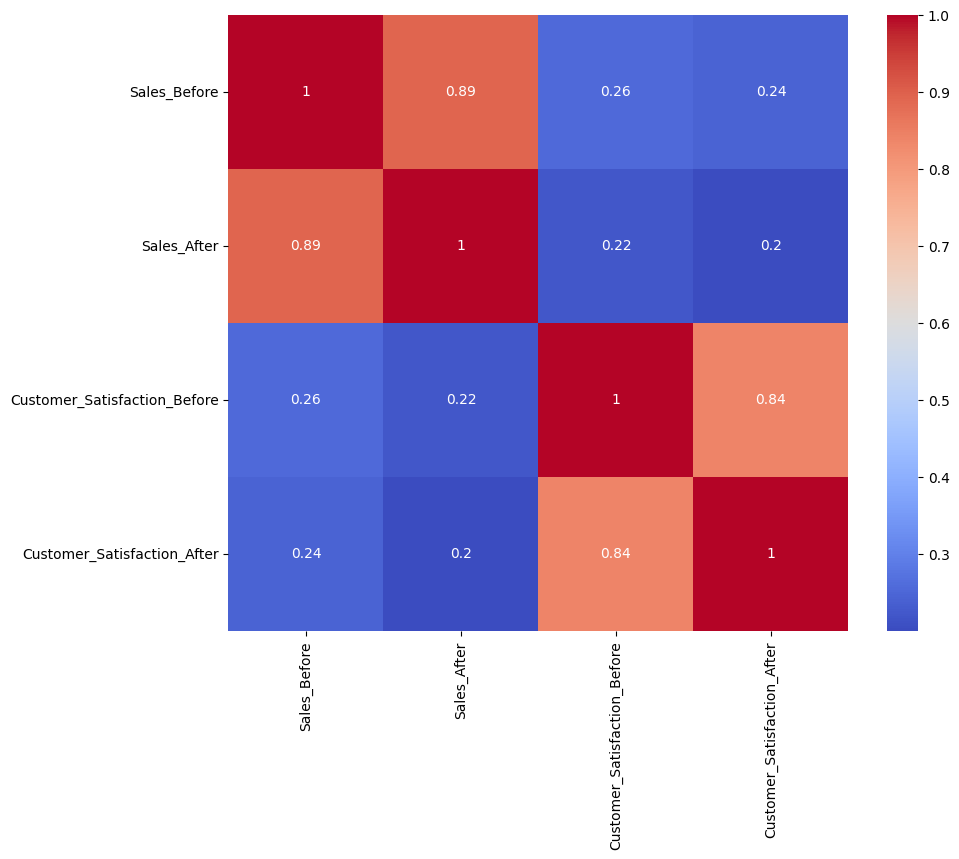

In [6]:
# Correlation heatmap to see if there are any correlation between features. 
# Only numerical.
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot= True, cmap = "coolwarm")
print(categorical_cols)

I use KNN for imputation of numeric missing values, and i remove all missing instances of missing data.

In [7]:
# Create a non imputated (dirty) and an imputated dataset for the model.
# Also drop na from non imputated so we can compare
df_dirty = df.copy()
imputed_df = df.copy()

# Set target name
target_name = 'Purchase_Made'


# Set up a checker, that only has the not null target feature and not null categorical instances.
# This is instead of using mode, as the performace was worse.
valid_instance = df[categorical_cols].copy().notnull()

# Remove all instances where the target value is missing
df_dirty = df.dropna(subset=[target_name]).copy()
imputed_df = df.dropna(subset=[target_name]).copy()

# Target data
target_data = df_dirty[target_name]

# KNN Imputation for numerical
knn_imputer = KNNImputer(n_neighbors=5)
imputed_df[numeric_columns] = knn_imputer.fit_transform(imputed_df[numeric_columns])


# Drop target feature in both datasets (And in other relevant elements)
df_dirty = df_dirty.drop(columns=[target_name])
imputed_df = imputed_df.drop(columns=[target_name])
categorical_cols_no_target = categorical_cols.drop(target_name)


# Mode imputation for cat features
#cat_imputer = SimpleImputer(strategy='most_frequent')
#imputed_df[categorical_cols_no_target] = cat_imputer.fit_transform(imputed_df[categorical_cols_no_target])


Setting up datasets for comparing scores in ML models

In [8]:
# Encoder for categorical features
df_dirty = pd.get_dummies(df_dirty)
imputed_df = pd.get_dummies(imputed_df)

print(df_dirty.info())
print(imputed_df.info())

# Align the imputed and non imputed datasets
df_dirty, imputed_df = df_dirty.align(imputed_df, join= "outer", axis = 1, fill_value=0)


<class 'pandas.core.frame.DataFrame'>
Index: 9195 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Sales_Before                   7787 non-null   float64
 1   Sales_After                    8489 non-null   float64
 2   Customer_Satisfaction_Before   7667 non-null   float64
 3   Customer_Satisfaction_After    7678 non-null   float64
 4   Group_Control                  9195 non-null   bool   
 5   Group_Treatment                9195 non-null   bool   
 6   Customer_Segment_High Value    9195 non-null   bool   
 7   Customer_Segment_Low Value     9195 non-null   bool   
 8   Customer_Segment_Medium Value  9195 non-null   bool   
dtypes: bool(5), float64(4)
memory usage: 404.1 KB
None
<class 'pandas.core.frame.DataFrame'>
Index: 9195 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------           

Compare the data with a ML model

In [9]:

# Split the data or both non imputed at imputed data so we can compare later
X_train_dirty, X_test_dirty, y_train_dirty, y_test_dirty = train_test_split(df_dirty,target_data, test_size=0.25, random_state=42)
X_train_imputed, X_test_imputed, y_train_imputed, y_test_imputed = train_test_split(imputed_df, target_data, test_size=0.25, random_state=42)

# Use Decision tree and compare
# Data with no imputations
model_dirty = DecisionTreeClassifier(random_state=42)
model_dirty.fit(X_train_dirty, y_train_dirty)
predict_dirty = model_dirty.predict(X_test_dirty)

# Imputed data model
model_clean = DecisionTreeClassifier(random_state=42)
model_clean.fit(X_train_imputed, y_train_imputed)
predict_clean = model_clean.predict(X_test_imputed)





# Evaluation for Non-Imputed (Dirty) Model
y_proba_dirty = model_dirty.predict_proba(X_test_dirty)[:, 1]

acc_dirty = accuracy_score(y_test_dirty, predict_dirty)
prec_dirty = precision_score(y_test_dirty, predict_dirty, pos_label="Yes")
rec_dirty = recall_score(y_test_dirty, predict_dirty, pos_label="Yes")
f1_dirty = f1_score(y_test_dirty, predict_dirty, pos_label="Yes")
roc_auc_dirty = roc_auc_score(y_test_dirty.map({'No': 0, 'Yes': 1}), y_proba_dirty)
cm_dirty = confusion_matrix(y_test_dirty, predict_dirty)

print("=== NON-Imputed (Dirty) Data Model Metrics ===")
print("Accuracy:  {:.3f}".format(acc_dirty))
print("Precision: {:.3f}".format(prec_dirty))
print("Recall:    {:.3f}".format(rec_dirty))
print("F1 Score:  {:.3f}".format(f1_dirty))
print("ROC AUC:   {:.3f}".format(roc_auc_dirty))
print("Confusion Matrix:")
print(cm_dirty)



# Evaluation for Imputed (Clean) Model
y_proba_clean = model_clean.predict_proba(X_test_imputed)[:, 1]

acc_clean = accuracy_score(y_test_imputed, predict_clean)
prec_clean = precision_score(y_test_imputed, predict_clean, pos_label="Yes")
rec_clean = recall_score(y_test_imputed, predict_clean, pos_label="Yes")
f1_clean = f1_score(y_test_imputed, predict_clean, pos_label="Yes")
roc_auc_clean = roc_auc_score(y_test_imputed.map({'No': 0, 'Yes': 1}), y_proba_clean)
cm_clean = confusion_matrix(y_test_imputed, predict_clean)

print("\n=== Imputed (Clean) Data Model Metrics ===")
print("Accuracy:  {:.3f}".format(acc_clean))
print("Precision: {:.3f}".format(prec_clean))
print("Recall:    {:.3f}".format(rec_clean))
print("F1 Score:  {:.3f}".format(f1_clean))
print("ROC AUC:   {:.3f}".format(roc_auc_clean))
print("Confusion Matrix:")
print(cm_clean)

=== NON-Imputed (Dirty) Data Model Metrics ===
Accuracy:  0.508
Precision: 0.525
Recall:    0.491
F1 Score:  0.507
ROC AUC:   0.509
Confusion Matrix:
[[587 527]
 [603 582]]

=== Imputed (Clean) Data Model Metrics ===
Accuracy:  0.502
Precision: 0.516
Recall:    0.527
F1 Score:  0.521
ROC AUC:   0.501
Confusion Matrix:
[[529 585]
 [561 624]]


Create 2 ratinal databases with costumer id and more in SQLite. These are saved as sales_data.db

In [10]:
# create a unique customer ID for each row
df['CustomerID'] = df.index + 1 

# Create customer table, with relavent "customer information", such as Customer_Segment and Group.
df_customers = df[['CustomerID', 'Group', 'Customer_Segment']].copy()


# Create a "sales" table, with everything that is sales relavent 
df_sales = df[['CustomerID', 'Sales_Before', 'Sales_After', 
               'Customer_Satisfaction_Before', 'Customer_Satisfaction_After', 
               'Purchase_Made']].copy()

# Create or connect to a sql database file
conn = sqlite3.connect("sales_data.db")
cur = conn.cursor()

# Create the Customers table
cur.execute('''
    CREATE TABLE IF NOT EXISTS Customers (
        CustomerID INTEGER PRIMARY KEY,
        Customer_Group TEXT,
        Customer_Segment TEXT
    )
''')

# Create the Sales table with a key to Customers
cur.execute('''
    CREATE TABLE IF NOT EXISTS Sales (
        CustomerID INTEGER,
        Sales_Before REAL,
        Sales_After REAL,
        Customer_Satisfaction_Before REAL,
        Customer_Satisfaction_After REAL,
        Purchase_Made TEXT,
        FOREIGN KEY(CustomerID) REFERENCES Customers(CustomerID)
    )
''')

# Insert data from dataframe into the tables
df_customers.to_sql('Customers', conn, if_exists='replace', index=False)
df_sales.to_sql('Sales', conn, if_exists='replace', index=False)

# Commit changes and close
conn.commit()
conn.close()
